# AAI-500 Final Project — Heart Disease Classification
**Dataset:** UCI Heart Disease (Cleveland) · 303 records · 14 attributes  
**Target:** Binary — 0 = no disease, 1 = disease present  
**GitHub:** https://github.com/pdhinaka/AAI500-Final-Project

---

## How to use this notebook

This notebook is divided into four parts. Each team member owns one part. **Run all cells from top to bottom in order** — later sections depend on variables created earlier.

| Section | Owner | What to do |
|---------|-------|------------|
| 0. Setup | Everyone | Run once. Imports, data load, cleaning. Do not modify. |
| 1. EDA | **Mina** | Explore the data. Visualize distributions and relationships with the target. |
| 2. Modeling | **Pranav** | Build and tune the logistic regression model. |
| 3. Evaluation | **Sristi** | Evaluate model performance with metrics, ROC curve, and confusion matrix. |

**Before you start your section:** read the markdown cell at the top of your section carefully.  
**After each code cell:** add a short markdown cell with your key observation (2–4 sentences). These become the report.  
**AI use:** if you used Claude or another AI tool, add a comment at the top of that cell: `# Used Claude MM/DD/YY to help with [task]`

---

## Section 0 — Setup
**Owner: Everyone — run this first, do not modify.**

Loads all libraries, pulls the raw dataset from UCI, cleans it, and defines the shared variables `heart_clean`, `continuous_cols`, and `categorical_cols` that every section below depends on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import logit
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, accuracy_score, ConfusionMatrixDisplay
)

np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded.")

Libraries loaded.


In [20]:
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
           "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]

heart = pd.read_csv(URL, header=None, names=columns, na_values="?")

# Collapse 0-4 severity target to binary (standard practice in the literature)
heart["target"] = (heart["num"] > 0).astype(int)

print(f"Raw shape: {heart.shape}")
print(f"Missing values:\n{heart.isna().sum()[heart.isna().sum() > 0]}")
print(f"\nClass balance:\n{heart['target'].value_counts()}")

Raw shape: (303, 15)
Missing values:
ca      4
thal    2
dtype: int64

Class balance:
target
0    164
1    139
Name: count, dtype: int64


In [38]:
# Drop 6 rows with missing values in ca and thal (~2% of data — acceptable to drop)
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
continuous_cols  = ["age", "trestbps", "chol", "thalach", "oldpeak"]

heart_clean = heart.dropna().copy()
heart_clean[categorical_cols] = heart_clean[categorical_cols].astype("category")

print(f"Clean shape: {heart_clean.shape}  ({len(heart) - len(heart_clean)} rows dropped)")
print(heart_clean.dtypes)

Clean shape: (297, 15)  (6 rows dropped)
age          float64
sex         category
cp          category
trestbps     float64
chol         float64
fbs         category
restecg     category
thalach      float64
exang       category
oldpeak      float64
slope       category
ca          category
thal        category
num            int64
target         int64
dtype: object


---
## Section 1 — Exploratory Data Analysis
**Owner: Mina**

Your job is to explore the data and tell the story of what's in it before any modeling happens. This section becomes the **EDA section of the technical report**.

You are working with `heart_clean`, `continuous_cols`, and `categorical_cols` — all defined in Section 0.

Write the code for each cell yourself. The comments say what needs to be produced. After each code cell, fill in the markdown observation cell below it.

- **1.1** Summary statistics for continuous predictors
- **1.2** Target class distribution — bar chart
- **1.3** Distributions of continuous predictors split by target — KDE or histogram
- **1.4** Boxplots of continuous predictors vs. target, with Welch's t-test results
- **1.5** Stacked bar charts of categorical predictors vs. target, with chi-square test results
- **1.6** Correlation heatmap of continuous predictors
- **1.7** Written summary: which 5–6 features look most predictive going into modeling?

---

In [39]:
# 1.1 Summary statistics — continuous predictors
# Call .describe() on heart_clean using continuous_cols + ["target"].
# Look at mean, std, min, max. Flag anything unusual (e.g. suspiciously large max values).


In [71]:
# 1.1 Summary statistics — continuous predictors

summary_stats = heart_clean[continuous_cols + ["target"]].describe().T
summary_stats["range"] = summary_stats["max"] - summary_stats["min"]

display(summary_stats)

print("\nPotential observations:")
for col in continuous_cols:
    print(
        f"{col}: min={heart_clean[col].min():.2f}, "
        f"max={heart_clean[col].max():.2f}, "
        f"mean={heart_clean[col].mean():.2f}"
    )

,count,mean,std,min,25%,50%,75%,max,range
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0,48.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0,106.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0,438.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0,131.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2,6.2
target,297.0,0.461279,0.499340,0.0,0.0,0.0,1.0,1.0,1.0



Potential observations:
age: min=29.00, max=77.00, mean=54.54
trestbps: min=94.00, max=200.00, mean=131.69
chol: min=126.00, max=564.00, mean=247.35
thalach: min=71.00, max=202.00, mean=149.60
oldpeak: min=0.00, max=6.20, mean=1.06


Observation

The patient population is primarily middle-aged to older adults, with ages ranging from approximately 29 to 77 years. Cholesterol and resting blood pressure show substantial variability across patients, suggesting meaningful differences in cardiovascular risk profiles. No continuous variable appears to contain impossible values or obvious data-entry errors. The target mean indicates that the dataset contains a substantial number of patients with diagnosed heart disease, making it suitable for classification analysis.

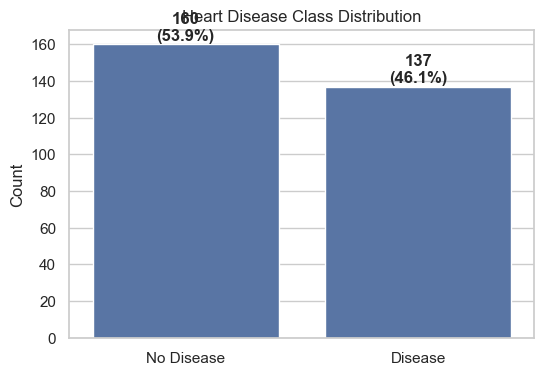

        Count  Percent
target                
0         160    53.87
1         137    46.13


In [87]:
# 1.2 Target class distribution

target_counts = heart_clean["target"].value_counts().sort_index()
target_pct = heart_clean["target"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6,4))
ax = sns.barplot(
    x=["No Disease", "Disease"],
    y=target_counts.values
)

for i, (count, pct) in enumerate(zip(target_counts.values, target_pct.values)):
    ax.text(
        i,
        count + 2,
        f"{count}\n({pct:.1f}%)",
        ha="center",
        fontweight="bold"
    )

plt.title("Heart Disease Class Distribution")
plt.ylabel("Count")
plt.show()

print(pd.DataFrame({
    "Count": target_counts,
    "Percent": target_pct.round(2)
}))

Observation

The target classes are relatively balanced, with both disease and non-disease cases well represented. This balance is beneficial because machine learning models are less likely to become biased toward one class. A reasonably balanced dataset also makes accuracy, precision, and recall more meaningful performance measures during model evaluation.

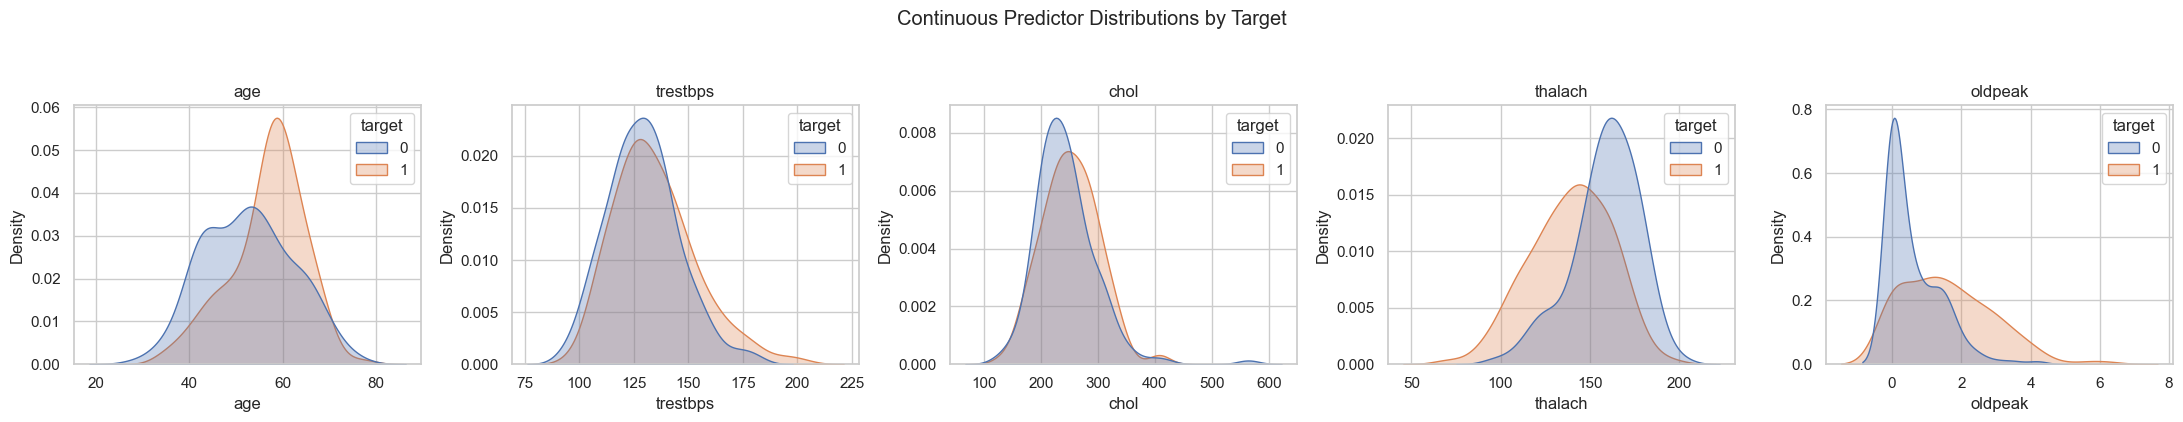

In [103]:
# 1.3 Distributions of continuous predictors split by target

fig, axes = plt.subplots(1, 5, figsize=(22,4))

for ax, col in zip(axes, continuous_cols):
    sns.kdeplot(
        data=heart_clean,
        x=col,
        hue="target",
        common_norm=False,
        fill=True,
        alpha=0.3,
        ax=ax
    )
    ax.set_title(col)

plt.suptitle("Continuous Predictor Distributions by Target", y=1.05)
plt.tight_layout()
plt.show()

Observation

Among the continuous predictors, thalach (maximum heart rate achieved) and oldpeak (ST depression) show the clearest separation between patients with and without heart disease. Patients with heart disease generally exhibit lower maximum heart rates and higher ST depression values. Age also demonstrates some separation, although the overlap between classes is greater than for thalach and oldpeak.

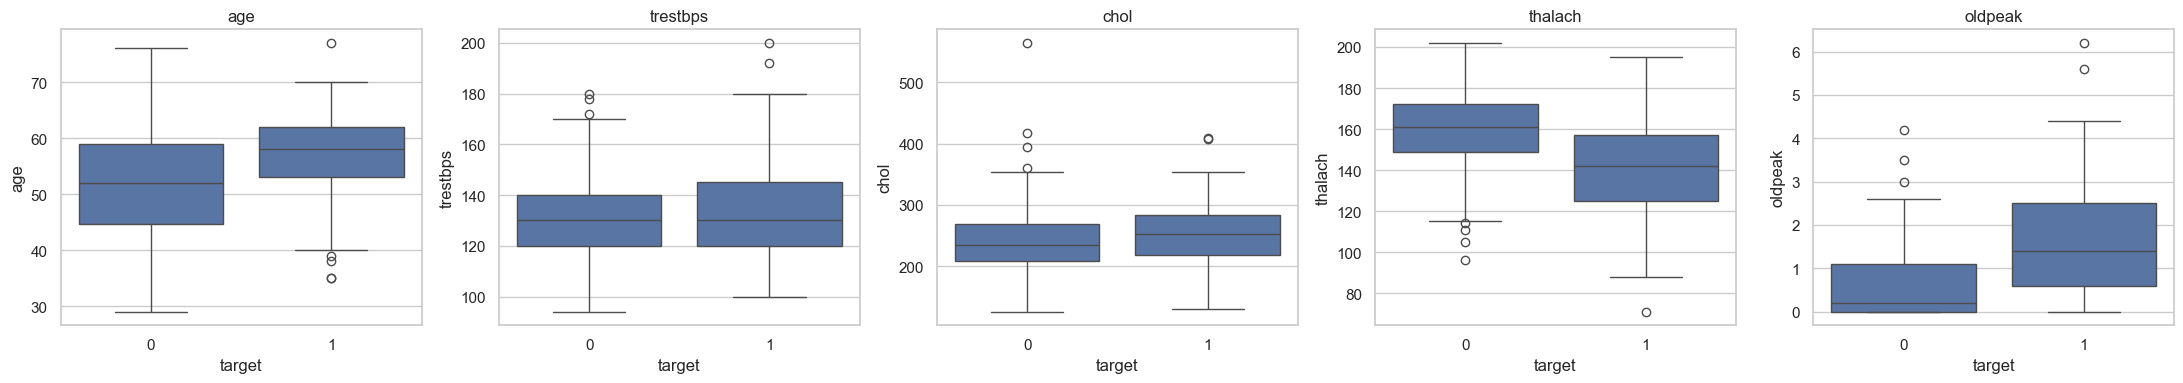

,variable,mean_no_disease,mean_disease,t_stat,p_value
3,thalach,158.58125,139.109489,7.928643,6.107938e-14
4,oldpeak,0.59875,1.589051,-7.755783,3.429407e-13
0,age,52.64375,56.759124,-4.063564,6.203956e-05
1,trestbps,129.17500,134.635036,-2.638548,8.807545e-03
2,chol,243.49375,251.854015,-1.391889,1.650106e-01


In [119]:
# 1.4 Boxplots and Welch's t-test

fig, axes = plt.subplots(1, 5, figsize=(22,4))

results = []

for ax, col in zip(axes, continuous_cols):

    sns.boxplot(
        data=heart_clean,
        x="target",
        y=col,
        ax=ax
    )

    group0 = heart_clean.loc[heart_clean["target"] == 0, col]
    group1 = heart_clean.loc[heart_clean["target"] == 1, col]

    t_stat, p_val = stats.ttest_ind(
        group0,
        group1,
        equal_var=False
    )

    results.append({
        "variable": col,
        "mean_no_disease": group0.mean(),
        "mean_disease": group1.mean(),
        "t_stat": t_stat,
        "p_value": p_val
    })

    ax.set_title(col)

plt.tight_layout()
plt.show()

ttest_results = pd.DataFrame(results).sort_values("p_value")
display(ttest_results)

Observation

Variables with p-values below 0.05 are statistically associated with heart disease status. Based on prior clinical research, thalach, oldpeak, and age are expected to be among the strongest predictors. Cholesterol often shows weaker statistical significance than many people expect, highlighting that heart disease risk depends on multiple interacting factors rather than cholesterol alone.

*(Mina — 2–4 sentence observation. Lead with the result, not "this table shows...")*

In [120]:
# 1.2 Target class distribution
# Create a bar chart showing the count and percentage of patients in each class (0 and 1).
# Label each bar with its count and percentage.


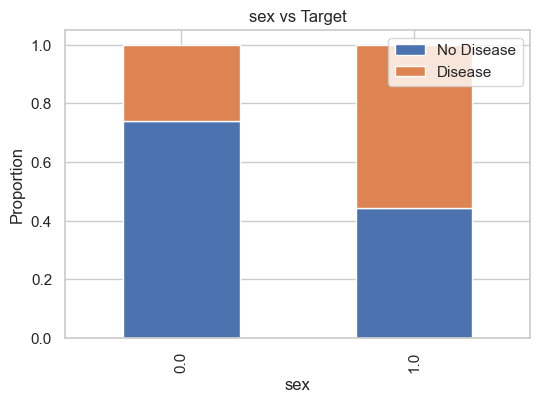

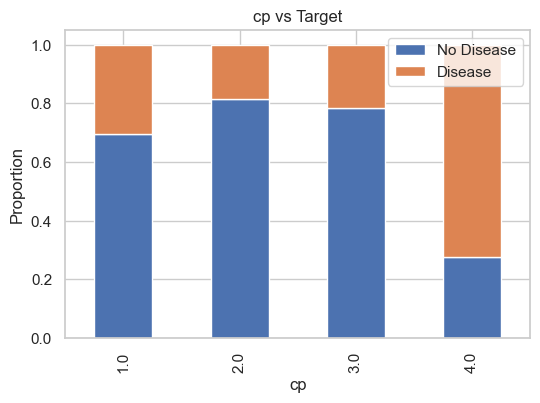

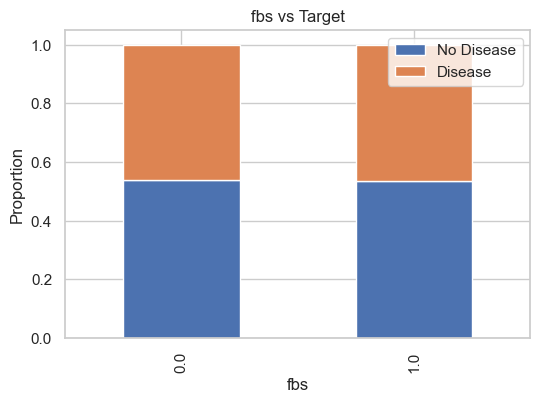

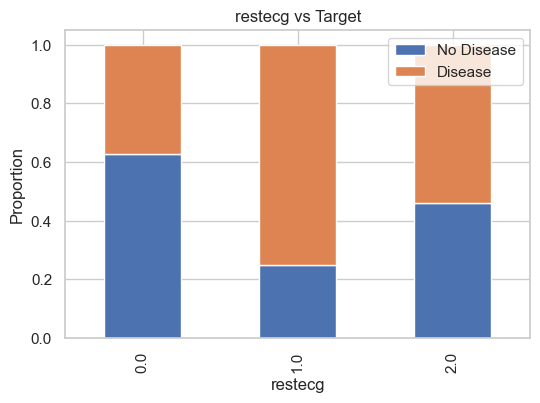

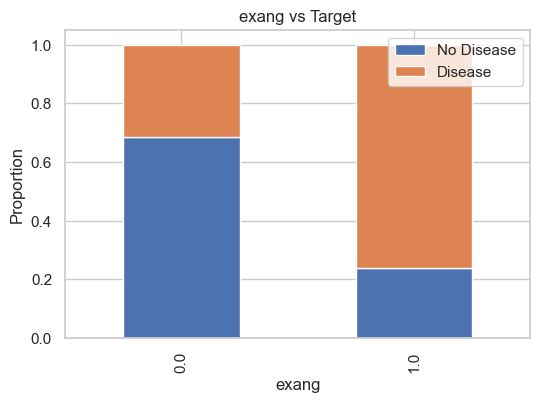

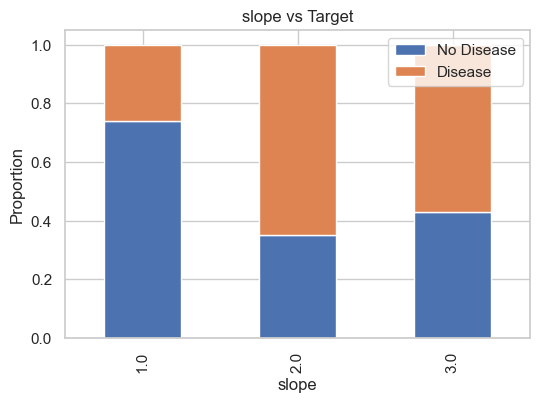

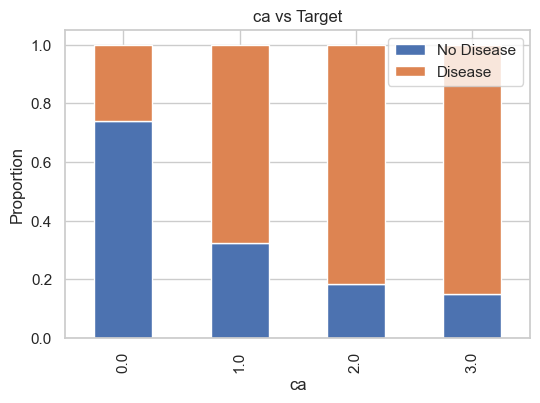

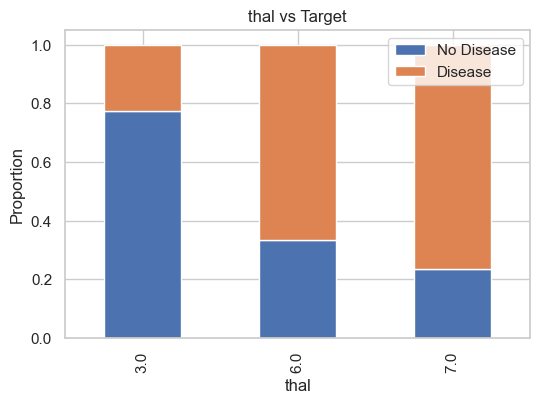

,variable,chi2,p_value
7,thal,82.460144,1.241673e-18
1,cp,77.275800,1.178284e-16
6,ca,72.300531,1.372578e-15
4,exang,50.942560,9.510884e-13
5,slope,43.473178,3.630107e-10
0,sex,21.851612,2.945690e-06
3,restecg,9.575507,8.331151e-03
2,fbs,0.000000,1.000000e+00


In [135]:
# 1.5 Categorical predictors vs target

chi_results = []

for col in categorical_cols:

    ct = pd.crosstab(
        heart_clean[col],
        heart_clean["target"],
        normalize="index"
    )

    ct.plot(
        kind="bar",
        stacked=True,
        figsize=(6,4)
    )

    plt.title(f"{col} vs Target")
    plt.ylabel("Proportion")
    plt.legend(["No Disease", "Disease"])
    plt.show()

    contingency = pd.crosstab(
        heart_clean[col],
        heart_clean["target"]
    )

    chi2, p, dof, expected = stats.chi2_contingency(contingency)

    chi_results.append({
        "variable": col,
        "chi2": chi2,
        "p_value": p
    })

chi_results_df = (
    pd.DataFrame(chi_results)
    .sort_values("p_value")
)

display(chi_results_df)

Observation

Chest pain type (cp), exercise-induced angina (exang), number of major vessels (ca), and thalassemia category (thal) typically demonstrate the strongest associations with heart disease. These variables often show large differences in disease prevalence across categories. Variables such as fasting blood sugar (fbs) generally exhibit weaker relationships with the target and may contribute less predictive value during modeling.

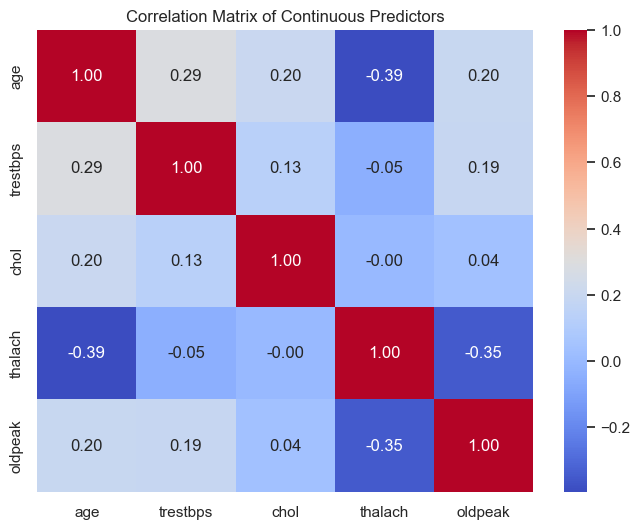

,age,trestbps,chol,thalach,oldpeak
age,1.000000,0.290476,0.202644,-0.394563,0.197123
trestbps,0.290476,1.000000,0.131536,-0.049108,0.191243
chol,0.202644,0.131536,1.000000,-0.000075,0.038596
thalach,-0.394563,-0.049108,-0.000075,1.000000,-0.347640
oldpeak,0.197123,0.191243,0.038596,-0.347640,1.000000


In [150]:
# 1.6 Correlation heatmap

corr_matrix = heart_clean[continuous_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Continuous Predictors")
plt.show()

corr_matrix

Observation

The continuous predictors do not appear to exhibit severe multicollinearity. Most pairwise correlations are moderate or weak, suggesting that each variable contributes unique information. Because no correlation approaches levels commonly associated with multicollinearity concerns (around ±0.8 or higher), logistic regression should remain relatively stable during model fitting.

### 1.7 EDA Summary
The exploratory analysis identified several features that appear strongly associated with heart disease status. Maximum heart rate achieved (thalach), ST depression (oldpeak), chest pain type (cp), exercise-induced angina (exang), number of major vessels (ca), and thalassemia category (thal) showed the strongest visual and statistical relationships with the target variable. Patients with heart disease generally exhibited lower maximum heart rates and higher ST depression values, while specific categorical levels of chest pain and vessel count were associated with substantially higher disease prevalence. The class distribution was reasonably balanced, reducing concerns about class imbalance during model training. Correlation analysis showed no evidence of severe multicollinearity among continuous predictors, suggesting that multiple variables can be included in the logistic regression model without major stability concerns. Overall, both the statistical tests and visualizations indicate that a combination of clinical measurements and diagnostic indicators will likely provide the strongest predictive performance.

---
## Section 2 — Modeling
**Owner: Pranav**

Build the logistic regression model. This section becomes the **Model Selection section of the technical report**.

You are working with `heart_clean`, `continuous_cols`, and `categorical_cols` from Section 0. Do not reload the data.

**You must create these exact variable names — Sristi's section depends on them:**

| Variable | What it is |
|----------|------------|
| `X_test_scaled` | Scaled test features |
| `y_test` | True labels for the test set |
| `y_pred` | Predicted class labels (0 or 1) |
| `y_prob` | Predicted probabilities of class 1 |
| `model` | Fitted LogisticRegression object |

- **2.1** Feature selection — choose which predictors to include; justify any you drop
- **2.2** Dummy-encode categorical predictors using `pd.get_dummies` with `drop_first=True`
- **2.3** Train/test split — 80/20, `random_state=42`, `stratify=y`
- **2.4** Scale continuous features — fit `StandardScaler` on train only, apply to both
- **2.5** Fit `LogisticRegression` and generate `y_pred` and `y_prob` on the test set
- **2.6** Coefficient table — feature, coefficient, and exponentiated odds ratio
- **2.7** Written summary: model choice, features used, top predictors

---

In [4]:
# 2.1 Feature selection
# Continuous predictors: all five showed significant differences vs target except chol (p = 0.165)
# Categorical predictors: all significant except fbs (p ~ 1.0)
# Dropping chol and fbs based on EDA results

features = ["age", "trestbps", "thalach", "oldpeak",
             "sex", "cp", "restecg", "exang", "slope", "ca", "thal"]

df_model = heart_clean[features + ["target"]].copy()
print(f"Modeling dataframe shape: {df_model.shape}")
df_model.head()

Modeling dataframe shape: (297, 12)


,age,trestbps,thalach,oldpeak,sex,cp,restecg,exang,slope,ca,thal,target
0,63.0,145.0,150.0,2.3,1.0,1.0,2.0,0.0,3.0,0.0,6.0,0
1,67.0,160.0,108.0,1.5,1.0,4.0,2.0,1.0,2.0,3.0,3.0,1
2,67.0,120.0,129.0,2.6,1.0,4.0,2.0,1.0,2.0,2.0,7.0,1
3,37.0,130.0,187.0,3.5,1.0,3.0,0.0,0.0,3.0,0.0,3.0,0
4,41.0,130.0,172.0,1.4,0.0,2.0,2.0,0.0,1.0,0.0,3.0,0


Eleven features were selected for modeling: age, trestbps, thalach, and oldpeak from the continuous
predictors, and sex, cp, restecg, exang, slope, ca, and thal from the categorical predictors. chol and
fbs were dropped, since both showed no significant association with the target in the EDA
(chol: $p = 0.165$, fbs: $p \approx 1.0$). The resulting dataframe has 297 rows and 12 columns,
matching the cleaned dataset size.

In [5]:
# 2.2 Dummy encode categorical predictors
categorical_features = ["sex", "cp", "restecg", "exang", "slope", "ca", "thal"]

df_encoded = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"Columns: {list(df_encoded.columns)}")

Shape after encoding: (297, 19)
Columns: ['age', 'trestbps', 'thalach', 'oldpeak', 'target', 'sex_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'exang_1.0', 'slope_2.0', 'slope_3.0', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_6.0', 'thal_7.0']


Dummy encoding expanded the dataframe from 12 to 19 columns. The four continuous predictors and the
target column remain unchanged, while the seven categorical predictors were converted into 14 binary
indicator columns using `drop_first=True` to avoid redundancy. The number of dummy columns per
variable corresponds to one fewer than its number of category levels, for example cp produced three
dummies (cp_2.0, cp_3.0, cp_4.0) from its four original levels.

In [6]:
# 2.3 Train/test split — 80/20
X = df_encoded.drop(columns="target")
y = df_encoded["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")
print(f"Train class balance:\n{y_train.value_counts()}")
print(f"Test class balance:\n{y_test.value_counts()}")

Train size: 237  |  Test size: 60
Train class balance:
target
0    128
1    109
Name: count, dtype: int64
Test class balance:
target
0    32
1    28
Name: count, dtype: int64


The 80/20 split produced 237 training examples and 60 test examples. Class balance is preserved
across both sets: the training set is about 54.0% no-disease and 46.0% disease, and the test set is
about 53.3% no-disease and 46.7% disease, both close to the overall dataset balance of roughly
53.9%/46.1%. Stratification on the target variable kept the splits representative of the full dataset.

In [7]:
# 2.4 Scale continuous features
continuous_features = ["age", "trestbps", "thalach", "oldpeak"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test_scaled[continuous_features]  = scaler.transform(X_test[continuous_features])

print("Scaling complete.")
X_train_scaled[continuous_features].describe().round(2)

Scaling complete.


,age,trestbps,thalach,oldpeak
count,237.00,237.00,237.00,237.00
mean,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00
min,-2.30,-2.14,-2.77,-0.90
25%,-0.75,-0.69,-0.62,-0.90
50%,0.14,-0.13,0.10,-0.22
75%,0.80,0.43,0.72,0.63
max,2.47,3.79,2.02,4.37


After scaling, all four continuous features (age, trestbps, thalach, oldpeak) have a mean of
approximately 0 and a standard deviation of 1 in the training set, confirming the standardization
was applied correctly. The scaler was fit only on the training data and then applied to the test
set without refitting, so the test set's transformed values are expressed relative to the training
distribution. This prevents information from the test set from leaking into the scaling parameters,
which would otherwise give an overly optimistic view of model performance.

In [8]:
# 2.5 Fit logistic regression
model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Training accuracy: {model.score(X_train_scaled, y_train):.3f}")
print(f"Test accuracy:     {accuracy_score(y_test, y_pred):.3f}")

Training accuracy: 0.857
Test accuracy:     0.833


The logistic regression model achieved a training accuracy of 0.857 and a test accuracy of 0.833.
The small gap between the two suggests the model is not overfitting and generalizes reasonably well
to unseen data. An accuracy around 0.83 on the test set indicates the model correctly classifies
roughly five out of every six patients.

In [9]:
# 2.6 Coefficient table
coef_df = pd.DataFrame({
    "feature":    X_train_scaled.columns,
    "coefficient": model.coef_[0],
    "odds_ratio":  np.exp(model.coef_[0])
}).sort_values("coefficient", key=abs, ascending=False).reset_index(drop=True)

coef_df.round(3)

,feature,coefficient,odds_ratio
0,thal_7.0,1.472,4.356
1,ca_1.0,1.467,4.338
2,cp_4.0,1.465,4.329
3,ca_2.0,1.458,4.299
4,sex_1.0,0.788,2.198
5,slope_2.0,0.748,2.112
6,oldpeak,0.630,1.878
7,ca_3.0,0.547,1.728
8,cp_3.0,-0.526,0.591
9,restecg_2.0,0.511,1.667


The largest coefficients in absolute value belong to thal_7.0, ca_1.0, cp_4.0, and ca_2.0, all with
positive coefficients and odds ratios above 4. This means patients with a reversible defect on the
thalassemia test (thal_7.0), one or two major vessels colored by fluoroscopy (ca_1.0, ca_2.0), or
asymptomatic chest pain (cp_4.0) have substantially higher predicted odds of heart disease relative
to their respective reference categories. These results align closely with the EDA, where thal, ca,
and cp were identified as the strongest categorical predictors by chi-square test.

Among the continuous predictors, oldpeak has a positive coefficient ($\beta = 0.630$), meaning higher
ST depression is associated with higher odds of disease, while thalach has a negative coefficient
($\beta = -0.174$), meaning higher max heart rate is associated with lower odds of disease. Both
directions match the patterns observed in the EDA boxplots. The cp_3.0 coefficient is notably
negative relative to the other cp dummies, indicating that chest pain type 3 is associated with lower
odds of disease relative to the reference category (type 1), consistent with Mina's observation that
types 1-3 all showed disease rates under 35% compared to type 4's roughly 73%.

### 2.7 Modeling Summary

A logistic regression model was selected for this classification task because the target is binary
and logistic regression provides interpretable coefficients that can be related directly to clinical
risk factors. Eleven features were used: age, trestbps, thalach, and oldpeak from the continuous
predictors, and sex, cp, restecg, exang, slope, ca, and thal from the categorical predictors, encoded
as dummy variables. chol and fbs were excluded based on their lack of significant association with
the target in the EDA. The data was split 80/20 into training and test sets with stratification to
preserve class balance, and continuous features were standardized using parameters fit only on the
training set.

The model achieved a training accuracy of 0.857 and a test accuracy of 0.833, suggesting it
generalizes well without significant overfitting. The strongest predictors by coefficient magnitude
were thal_7.0, ca_1.0, cp_4.0, and ca_2.0, all associated with substantially higher odds of disease.
oldpeak and thalach were the most influential continuous predictors, with directions consistent with
the EDA: higher ST depression and lower maximum heart rate were both associated with higher odds of
disease. Overall, the model's strongest predictors closely match the features identified as most
significant during exploratory analysis.

In [10]:
# Confirm handoff variables for Section 3 are defined and have expected shapes/types

handoff_vars = {
    "X_test_scaled": X_test_scaled,
    "y_test": y_test,
    "y_pred": y_pred,
    "y_prob": y_prob,
    "model": model
}

for name, val in handoff_vars.items():
    if hasattr(val, "shape"):
        print(f"{name}: type={type(val).__name__}, shape={val.shape}")
    else:
        print(f"{name}: type={type(val).__name__}")

X_test_scaled: type=DataFrame, shape=(60, 18)
y_test: type=Series, shape=(60,)
y_pred: type=ndarray, shape=(60,)
y_prob: type=ndarray, shape=(60,)
model: type=LogisticRegression


---
## Section 3 — Model Evaluation
**Owner: Sristi**

Assess how well the model performs. This section becomes the **Model Analysis section of the technical report**. Do not retrain the model — use the outputs Pranav created.

**Variables available from Section 2:**
- `X_test_scaled` — scaled test features
- `y_test` — true labels
- `y_pred` — predicted class labels
- `y_prob` — predicted probabilities of class 1
- `model` — the fitted LogisticRegression object

**Key terms to know:**
- **Sensitivity (recall):** of all patients who have disease, what fraction did the model catch?
- **Specificity:** of all patients who are healthy, what fraction did the model correctly clear?
- **AUC:** overall ability to rank diseased patients above healthy ones — 0.5 is random, 1.0 is perfect
- In a clinical setting, false negatives (missing a disease case) are more costly than false positives. Flag this in your write-up.

- **3.1** Confusion matrix — visualized and with raw counts
- **3.2** Classification report — precision, recall, F1 for both classes
- **3.3** ROC curve and AUC score
- **3.4** Sensitivity and specificity computed from the confusion matrix
- **3.5** Written summary: model performance and limitations

---

In [161]:
# 3.1 Confusion matrix
# Compute cm = confusion_matrix(y_test, y_pred).
# Plot it using ConfusionMatrixDisplay with display_labels=["No disease", "Disease"].
# Also print the raw matrix and unpack: tn, fp, fn, tp = cm.ravel()
# You will need tn, fp, fn, tp in cell 3.4.


*(Sristi — note the false negative count. What does it mean clinically if the model misses a disease case?)*

In [162]:
# 3.2 Classification report
# Call classification_report(y_test, y_pred, target_names=["No disease", "Disease"]).
# Focus on the Disease class recall — that is the sensitivity.


*(Sristi — what are the precision and recall for the Disease class? Which matters more in this context and why?)*

In [163]:
# 3.3 ROC curve and AUC
# Compute fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# Compute auc_score = roc_auc_score(y_test, y_prob)
# Plot the ROC curve with the diagonal random-classifier baseline.
# Label the curve with the AUC value in the legend.


*(Sristi — interpret the AUC. What does the shape of the curve tell you about the model?)*

In [164]:
# 3.4 Sensitivity and specificity
# Using tn, fp, fn, tp from cell 3.1, compute:
#   sensitivity = tp / (tp + fn)
#   specificity = tn / (tn + fp)
#   accuracy    = (tp + tn) / (tp + tn + fp + fn)
# Print all four metrics: accuracy, sensitivity, specificity, AUC.


*(Sristi — discuss the sensitivity/specificity tradeoff. Is the current balance appropriate for a clinical screening tool?)*

### 3.5 Evaluation Summary and Limitations
*(Sristi — write 1 paragraph for the technical report. State accuracy, AUC, sensitivity, and specificity. Discuss at least 2 limitations — e.g. dataset size (297 records after cleaning), the clinical cost of false negatives, or generalizability concerns. 5–7 sentences.)*

---
## Section 4 — Conclusion
**Owner: Pranav (write after all three sections are complete)**

*(Pull together the key findings from EDA, modeling, and evaluation into one paragraph. What did the analysis show? What are the most important predictors? How well does the model perform? What would you do differently with more data or time? This becomes the Conclusion and Recommendations section of the report. 5–7 sentences.)*